In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
from collections import Counter
from sklearn.metrics import precision_score, recall_score
import seaborn as sns

# 1. Определение вспомогательных функций

In [ ]:
def uncertainty_least_confidence(proba):
    """1 - max(P) - чем больше, тем выше неуверенность."""

    return 1 - np.max(proba, axis=1)

def uncertainty_margin(proba):
    """Разница между вероятностями двух самых вероятных классов."""

    sorted_proba = np.sort(proba, axis=1)[:, ::-1]
    return sorted_proba[:, 0] - sorted_proba[:, 1]

def uncertainty_entropy(proba):
    """Энтропия распределения вероятностей."""

    return entropy(proba.T)

def qbc_disagreement(proba_list):
    """
    Query-By-Committee: disagreement измеряется через энтропию голосования комитета.
    proba_list: список массивов вероятностей от каждой модели комитета.
    """

    # Усреднённое распределение вероятностей по комитету
    avg_proba = np.mean(proba_list, axis=0)
    return entropy(avg_proba.T)

def active_learning_loop_with_report(
    strategy, X_init, y_init, X_pool, y_pool_true,
    X_test, y_test, model_class, n_queries=10, query_size=20,
    class_names=None, random_state=42, **model_kwargs
):
    """
    Цикл активного обучения с оценкой качества по macro F1-score и отслеживанием per-class F1.
    Также выводит распределение классов, выбранных для разметки на каждом шаге.

    Возвращает:
        final_model    - обученная модель на последнем шаге
        X_labeled      - финальный набор размеченных признаков
        y_labeled      - финальные метки
        test_scores    - список macro F1 после каждого запроса
        per_class_f1_history - словарь с историей F1 для каждого класса
    """

    X_labeled = X_init.copy()
    y_labeled = y_init.copy()
    X_unlabeled = X_pool.copy()
    y_unlabeled_true = y_pool_true.copy()

    test_scores = []                # macro F1
    per_class_f1_history = {i: [] for i in np.unique(y_test)}  # F1-score для каждого класса

    per_class_precision_history = {i: [] for i in np.unique(y_test)}
    per_class_recall_history = {i: [] for i in np.unique(y_test)}

    # Инициализация моделей для QBC
    if strategy == 'qbc':
        models = [
            RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1),
            LogisticRegression(max_iter=2000, solver='saga', random_state=random_state),
            SVC(probability=True, random_state=random_state),
        ]
    else:
        model = model_class(random_state=random_state, **model_kwargs)

    for query in range(n_queries):
        if strategy == 'qbc':
            proba_list = []
            for m in models:
                m.fit(X_labeled, y_labeled)
                proba = m.predict_proba(X_unlabeled)
                proba_list.append(proba)
            scores = qbc_disagreement(proba_list)
            query_indices = np.argsort(scores)[-query_size:]
        else:
            model.fit(X_labeled, y_labeled)
            proba = model.predict_proba(X_unlabeled)
            if strategy == 'least_conf':
                scores = uncertainty_least_confidence(proba)
            elif strategy == 'margin':
                scores = uncertainty_margin(proba)
            elif strategy == 'entropy':
                scores = uncertainty_entropy(proba)
            else:
                raise ValueError("Unknown strategy")
            query_indices = np.argsort(scores)[-query_size:]

        # Добавляем размеченные образцы
        X_new = X_unlabeled[query_indices]
        y_new = y_unlabeled_true[query_indices]
        X_labeled = np.vstack([X_labeled, X_new])
        y_labeled = np.concatenate([y_labeled, y_new])

        # Информация о выбранных классах
        selected_counts = Counter(y_new)
        print(f"\nQuery {query+1} - выбраны классы для разметки:")
        for cls, count in sorted(selected_counts.items()):
            cls_name = class_names[cls] if class_names is not None else str(cls)
            print(f"  Класс {cls} ({cls_name}): {count} объектов")

        # Удаляем из пула
        mask = np.ones(X_unlabeled.shape[0], dtype=bool)
        mask[query_indices] = False
        X_unlabeled = X_unlabeled[mask]
        y_unlabeled_true = y_unlabeled_true[mask]

        # Оценка на тесте (macro F1 и per-class F1)
        if strategy == 'qbc':
            eval_model = models[0]
            eval_model.fit(X_labeled, y_labeled)
        else:
            eval_model = model_class(random_state=random_state, **model_kwargs)
            eval_model.fit(X_labeled, y_labeled)

        y_pred = eval_model.predict(X_test)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        test_scores.append(f1_macro)

        prec_per_class = precision_score(y_test, y_pred, average=None)
        rec_per_class = recall_score(y_test, y_pred, average=None)

        for cls, prec_val, rec_val in zip(np.unique(y_test), prec_per_class, rec_per_class):
            per_class_precision_history[cls].append(prec_val)
            per_class_recall_history[cls].append(rec_val)

        # Per-class F1
        f1_per_class = f1_score(y_test, y_pred, average=None)
        for cls, f1_val in zip(np.unique(y_test), f1_per_class):
            per_class_f1_history[cls].append(f1_val)

        print(f"Test F1-macro: {f1_macro:.4f}")
        print("Per-class F1:", {class_names[cls] if class_names else cls: round(f1,4)
                                 for cls, f1 in zip(np.unique(y_test), f1_per_class)})

    # Финальная модель
    if strategy == 'qbc':
        final_model = models[0]
        final_model.fit(X_labeled, y_labeled)
    else:
        final_model = model_class(random_state=random_state, **model_kwargs)
        final_model.fit(X_labeled, y_labeled)

    # Финальный отчёт
    y_pred_final = final_model.predict(X_test)
    print("\n=== Финальный отчёт ===")
    print(classification_report(y_test, y_pred_final, target_names=class_names))

    # Матрица ошибок
    cm = confusion_matrix(y_test, y_pred_final)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix (Final Model)')
    plt.show()

    return (final_model, X_labeled, y_labeled, test_scores,
        per_class_f1_history, per_class_precision_history, per_class_recall_history)

# 2. Загрузка и подготовка данных

In [ ]:
df = pd.read_parquet("anem_with_features_20_04.parquet")
df = df.drop(columns=['WBC', 'PLT'])
df = df[df['label'] <= 4]

feature_cols = [c for c in df.columns if c != 'label']
X = df[feature_cols].copy()
y = df['label'].copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

class_names = [
    "Норма", "Анемия B12", "Железодефицитная анемия",
    "Фолиеводефицитная анемия", "Бета-талассемия"
]

# 3. Формирование начальной размеченной выборки и неразмеченного пула

In [ ]:
initial_size = 200 # Начальный размер размеченных данных
X_initial, X_pool, y_initial, y_pool = train_test_split(
    X_train_full_scaled, y_train_full, train_size=initial_size,
    random_state=42, stratify=y_train_full
)
y_initial = y_initial.values
y_pool = y_pool.values

# 4. Запуск активного обучения (Least Confidence)

=== Активное обучение (Least Confidence) ===

Query 1 - выбраны классы для разметки:
  Класс 0 (Норма): 2 объектов
  Класс 1 (Анемия B12): 2 объектов
  Класс 2 (Железодефицитная анемия): 9 объектов
  Класс 3 (Фолиеводефицитная анемия): 5 объектов
  Класс 4 (Бета-талассемия): 2 объектов
Test F1-macro: 0.4528
Per-class F1: {'Норма': np.float64(0.9927), 'Анемия B12': np.float64(0.1176), 'Железодефицитная анемия': np.float64(0.8351), 'Фолиеводефицитная анемия': np.float64(0.0784), 'Бета-талассемия': np.float64(0.24)}

Query 2 - выбраны классы для разметки:
  Класс 0 (Норма): 2 объектов
  Класс 1 (Анемия B12): 2 объектов
  Класс 2 (Железодефицитная анемия): 5 объектов
  Класс 3 (Фолиеводефицитная анемия): 2 объектов
  Класс 4 (Бета-талассемия): 9 объектов
Test F1-macro: 0.5677
Per-class F1: {'Норма': np.float64(0.9923), 'Анемия B12': np.float64(0.125), 'Железодефицитная анемия': np.float64(0.8369), 'Фолиеводефицитная анемия': np.float64(0.0444), 'Бета-талассемия': np.float64(0.84)}

Query 3

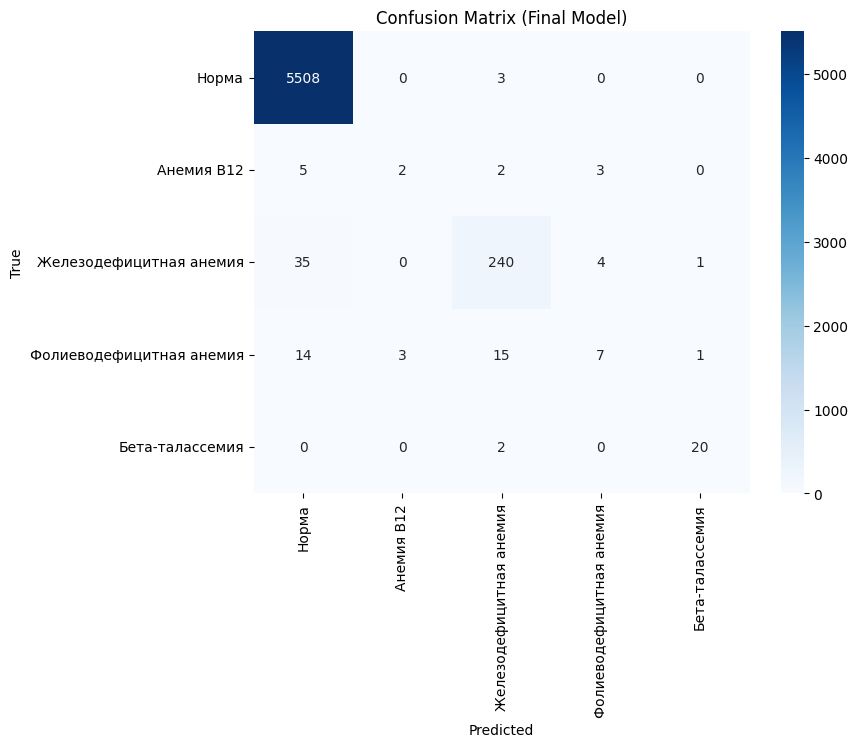

In [ ]:
print("=== Активное обучение (Least Confidence) ===")
final_model, X_labeled, y_labeled, macro_f1_history, per_class_f1_hist, _, _ = \
    active_learning_loop_with_report(
        strategy='least_conf', # Можно пробовать другие стратегии
        X_init=X_initial,
        y_init=y_initial,
        X_pool=X_pool,
        y_pool_true=y_pool,
        X_test=X_test_scaled,
        y_test=y_test,
        model_class=RandomForestClassifier,
        n_queries=25,
        query_size=20,
        class_names=class_names,
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    )

# 5. Финальный отчет


=== Финальный отчёт (после 25 запросов) ===
                          precision    recall  f1-score   support

                   Норма       0.99      1.00      0.99      5511
              Анемия B12       0.40      0.17      0.24        12
 Железодефицитная анемия       0.92      0.86      0.89       280
Фолиеводефицитная анемия       0.50      0.17      0.26        40
         Бета-талассемия       0.91      0.91      0.91        22

                accuracy                           0.98      5865
               macro avg       0.74      0.62      0.66      5865
            weighted avg       0.98      0.98      0.98      5865



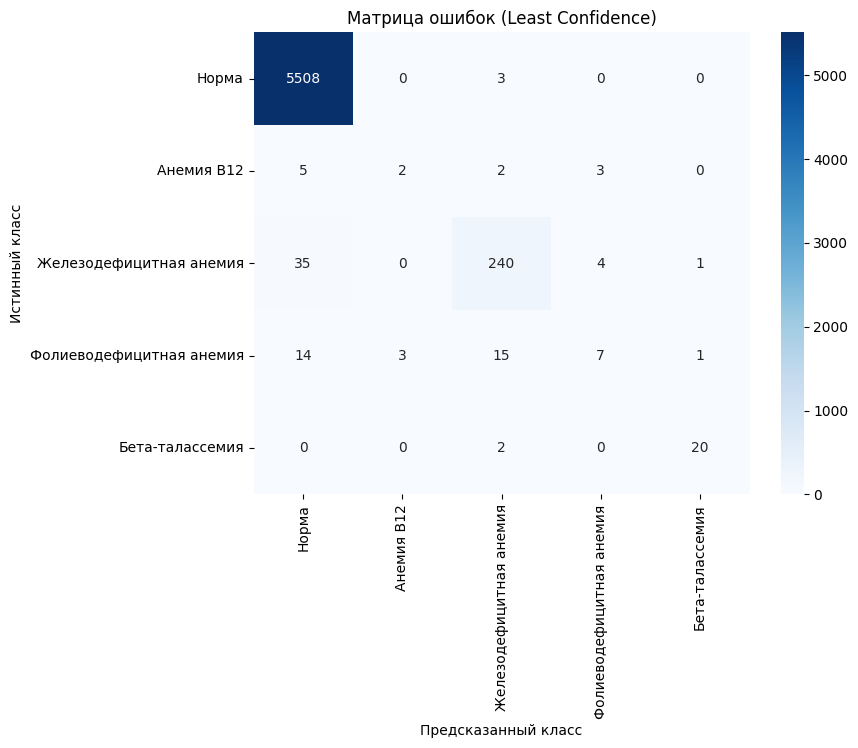

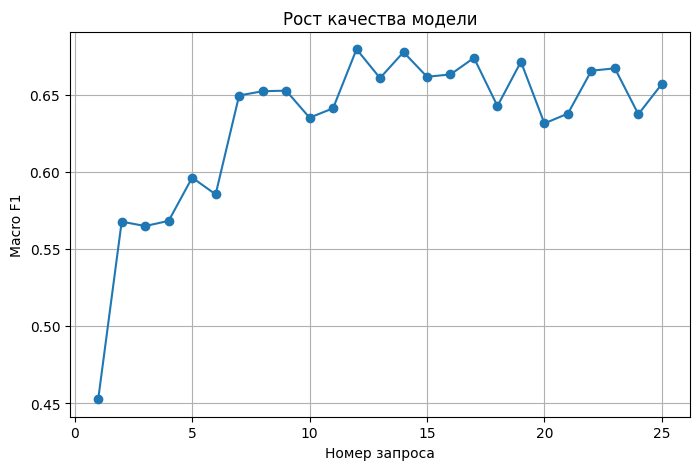

In [ ]:
print("\n=== Финальный отчёт (после 25 запросов) ===")
y_pred_final = final_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_final, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок (Least Confidence)')
plt.show()

# График динамики Macro F1
plt.figure(figsize=(8,5))
plt.plot(range(1, len(macro_f1_history)+1), macro_f1_history, marker='o')
plt.xlabel('Номер запроса')
plt.ylabel('Macro F1')
plt.title('Рост качества модели')
plt.grid(True)
plt.show()

# Сохранение модели и scaler

In [ ]:
import joblib

joblib.dump(final_model, 'final_model_least_conf.joblib')
joblib.dump(scaler, 'scaler_least_conf.joblib')
print("Модель и scaler сохранены в файлы 'final_model_least_conf.joblib' и 'scaler_least_conf.joblib'")

Модель и scaler сохранены в файлы 'final_model_least_conf.joblib' и 'scaler_least_conf.joblib'
